In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os

# 1. Force a clean restart of the local folder
print("Cleaning up local disk...")
!rm -rf /content/LocalImageDataset

# 2. Use the terminal 'cp' command (it's often more stable than shutil for Drive)
print("Copying images using Terminal mode... please wait.")
!cp -r "/content/drive/MyDrive/ImageDataset" "/content/LocalImageDataset"

print("Copying complete! Now you can proceed to the Data Preprocessing (Part 3).")


Cleaning up local disk...
Copying images using Terminal mode... please wait.
Copying complete! Now you can proceed to the Data Preprocessing (Part 3).


In [5]:
import tensorflow as tf

img_height, img_width = 224, 224
batch_size = 32
dataset_path = "/content/LocalImageDataset"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Ready with 224x224 images for Lab 5!")


Found 6299 files belonging to 20 classes.
Using 5040 files for training.
Found 6299 files belonging to 20 classes.
Using 1259 files for validation.
Ready with 224x224 images for Lab 5!


In [6]:
from tensorflow.keras import layers, models

def build_model(base_model):
    base_model.trainable = False # We use Transfer Learning
    model = models.Sequential([
        layers.Rescaling(1./255, input_shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(len(class_names))
    ])
    return model


In [7]:
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2

# This creates a dictionary of our 3 racers
models_dict = {
    "VGG16": VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3)),
    "ResNet50": ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3)),
    "MobileNetV2": MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
}

print("Our 3 competitors are ready for the race!")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Our 3 competitors are ready for the race!


In [8]:
from tensorflow.keras.optimizers import Adam

histories = {}
trained_models = {}

for name, base in models_dict.items():
    print(f"\n🚀 STARTING RACE: Training {name}...")

    # 1. Build the specific model
    model = build_model(base)

    # 2. Compile
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    # 3. Train for 10 epochs
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        verbose=1
    )

    # 4. Save the results
    histories[name] = history
    trained_models[name] = model
    print(f"✅ {name} has finished the race!")

print("\n🏆 ALL MODELS HAVE FINISHED TRAINING!")



🚀 STARTING RACE: Training VGG16...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


158/158 ━━━━━━━━━━━━━━━━━━━━ 75s 363ms/step - accuracy: 0.0710 - loss: 3.1276 - val_accuracy: 0.1247 - val_loss: 2.9158
Epoch 2/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 40s 252ms/step - accuracy: 0.0980 - loss: 2.9296 - val_accuracy: 0.1890 - val_loss: 2.8371
Epoch 3/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 38s 240ms/step - accuracy: 0.1506 - loss: 2.8366 - val_accuracy: 0.2526 - val_loss: 2.7716
Epoch 4/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 38s 238ms/step - accuracy: 0.1786 - loss: 2.7626 - val_accuracy: 0.2669 - val_loss: 2.7085
Epoch 5/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 37s 237ms/step - accuracy: 0.2169 - loss: 2.7008 - val_accuracy: 0.2891 - val_loss: 2.6418
Epoch 6/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 37s 237ms/step - accuracy: 0.2335 - loss: 2.6438 - val_accuracy: 0.3161 - val_loss: 2.5765
Epoch 7/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 38s 238ms/step - accuracy: 0.2567 - loss: 2.5789 - val_accuracy: 0.3320 - val_loss: 2.5159
Epoch 8/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 38s 240ms/step - accuracy: 0.2730 - loss: 2.5178 - val

In [9]:
from sklearn.metrics import classification_report
import numpy as np

# We loop through our 3 trained models
for name, model in trained_models.items():
    print(f"\n📊 --- CLASSIFICATION REPORT: {name} ---")

    y_true, y_pred = [], []
    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    print(classification_report(y_true, y_pred, target_names=class_names))



📊 --- CLASSIFICATION REPORT: VGG16 ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                           precision    recall  f1-score   support

               Broom moss       0.45      0.46      0.46        63
      Common haircap moss       0.31      0.58      0.41        67
    Common smoothcap moss       0.33      0.02      0.04        53
                Cord moss       0.25      0.69      0.36        49
Cypress-leaved plait moss       0.28      0.12      0.16        68
       Delicate fern moss       0.42      0.50      0.45        60
                Fire moss       0.39      0.32      0.35        63
   Grey-cushioned grimmia       0.41      0.55      0.47        77
          Heath star moss       0.00      0.00      0.00        55
        Hoary fringe moss       0.44      0.32      0.37        68
                Peat moss       0.33      0.08      0.13        63
          Pincushion moss       0.44      0.81      0.57        69
 Red-stemmed feather moss       0.69      0.30      0.41        81
              Silver moss       0.28      0.59      0.38     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                           precision    recall  f1-score   support

               Broom moss       0.10      0.48      0.17        63
      Common haircap moss       0.00      0.00      0.00        67
    Common smoothcap moss       0.00      0.00      0.00        53
                Cord moss       0.09      0.08      0.08        49
Cypress-leaved plait moss       0.00      0.00      0.00        68
       Delicate fern moss       0.00      0.00      0.00        60
                Fire moss       0.00      0.00      0.00        63
   Grey-cushioned grimmia       0.11      0.42      0.17        77
          Heath star moss       0.00      0.00      0.00        55
        Hoary fringe moss       0.17      0.06      0.09        68
                Peat moss       0.00      0.00      0.00        63
          Pincushion moss       0.15      0.68      0.24        69
 Red-stemmed feather moss       0.00      0.00      0.00        81
              Silver moss       0.13      0.62      0.22     

Generating Confusion Matrix for VGG16...


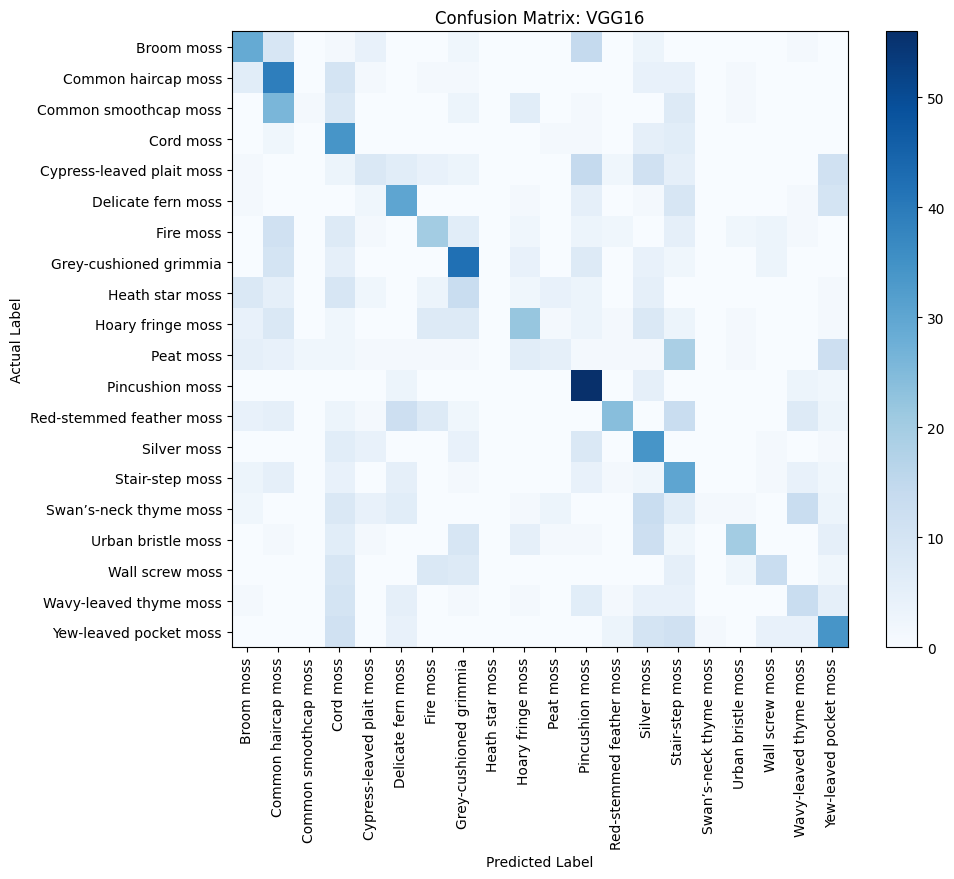

Generating Confusion Matrix for ResNet50...


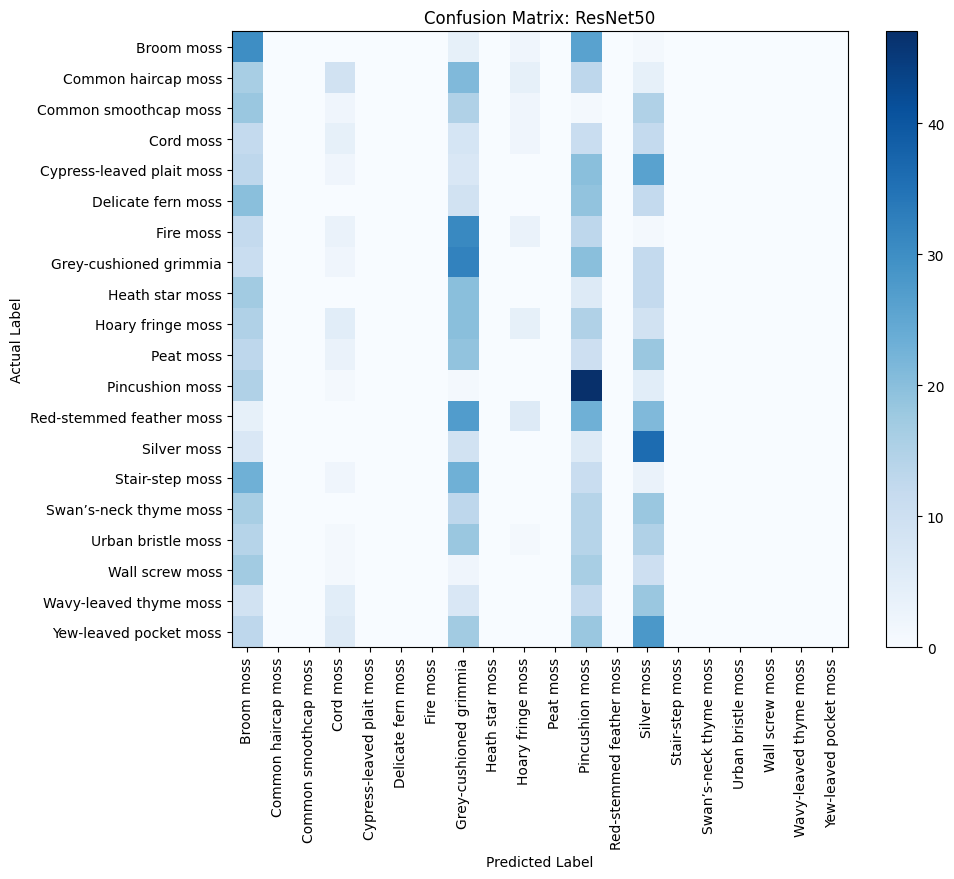

Generating Confusion Matrix for MobileNetV2...


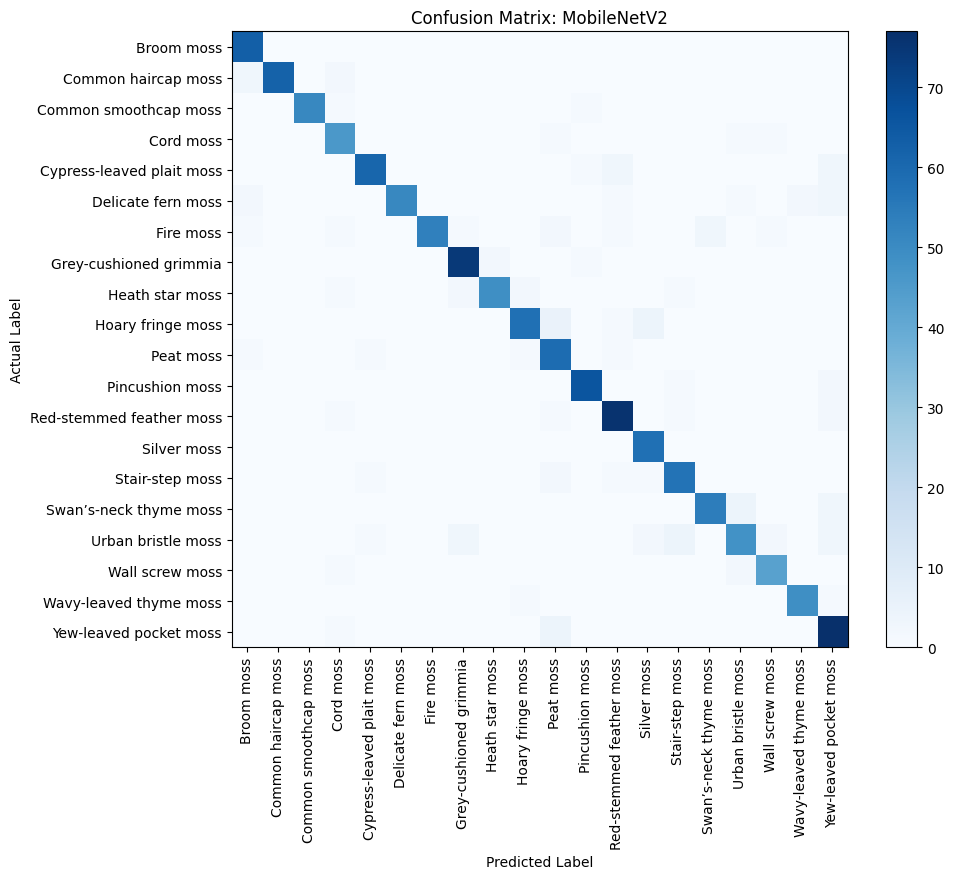

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

for name, model in trained_models.items():
    print(f"Generating Confusion Matrix for {name}...")
    y_true, y_pred = [], []
    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()


Generating ROC Curve for VGG16...


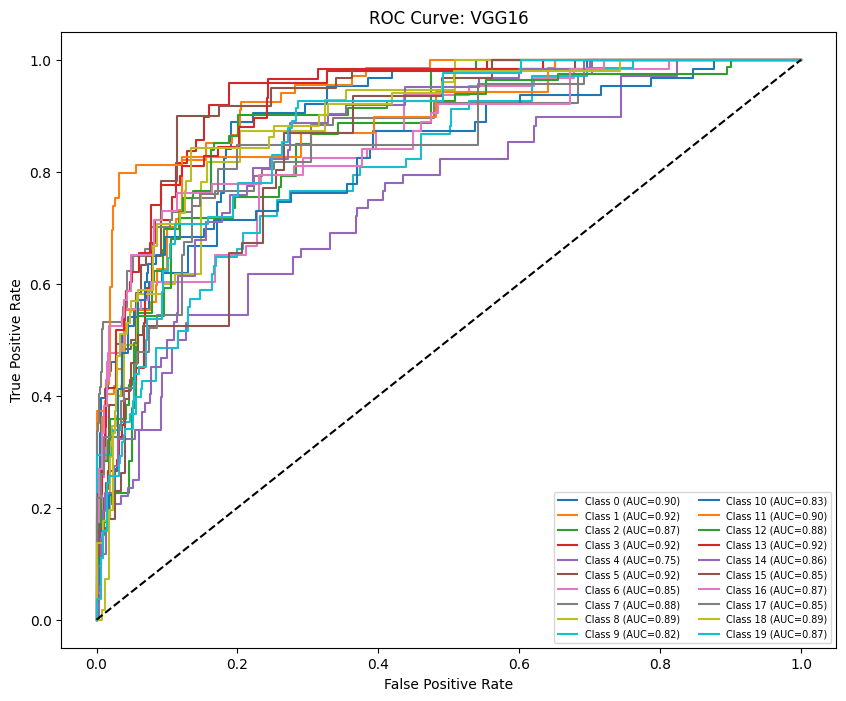

Generating ROC Curve for ResNet50...


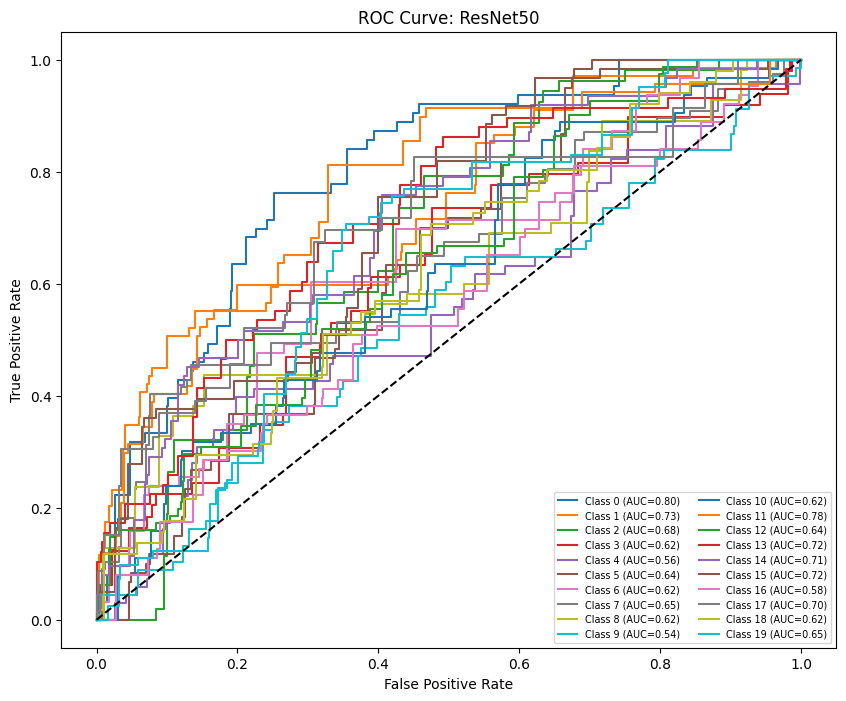

Generating ROC Curve for MobileNetV2...


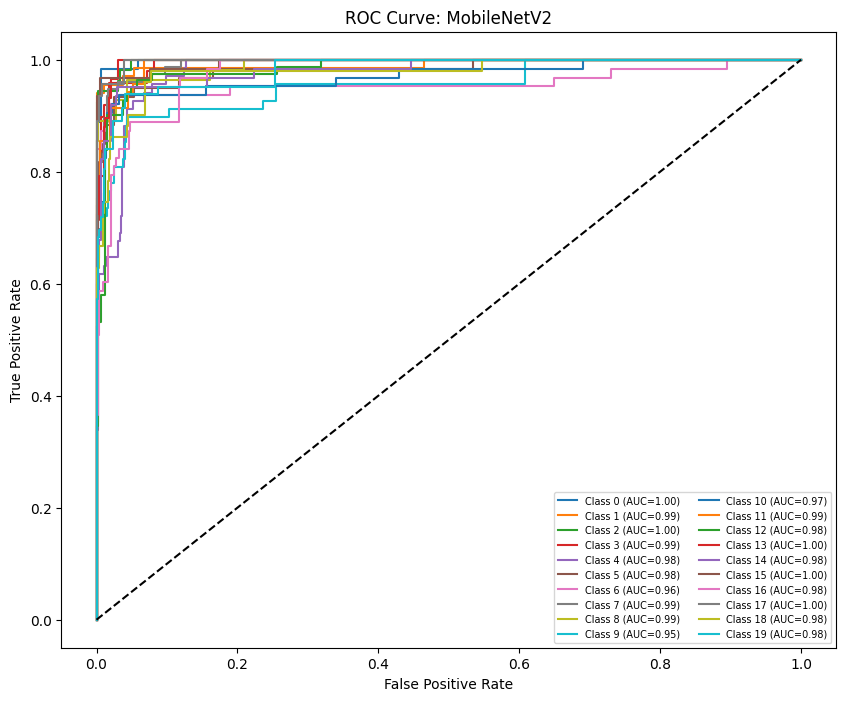

In [11]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

for name, model in trained_models.items():
    print(f"Generating ROC Curve for {name}...")

    # 1. Collect true labels and raw probability scores
    y_true, y_prob = [], []
    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_prob.extend(preds)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    # 2. Binarize labels for multi-class ROC
    y_bin = label_binarize(y_true, classes=range(len(class_names)))

    plt.figure(figsize=(10, 8))
    # 3. Plot curve for each species
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f'Class {i} (AUC={auc(fpr, tpr):.2f})')

    plt.plot([0, 1], [0, 1], 'k--') # Diagonal line for "Random Guessing"
    plt.title(f"ROC Curve: {name}")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right", fontsize='x-small', ncol=2)
    plt.show()


🔥 Universal Grad-CAM for VGG16...


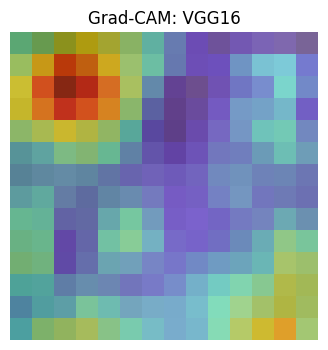

🔥 Universal Grad-CAM for ResNet50...


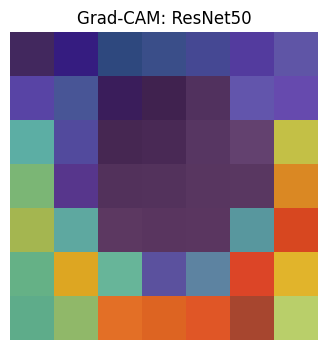

🔥 Universal Grad-CAM for MobileNetV2...


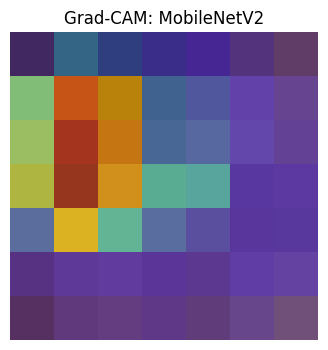

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def get_gradcam_universal(full_model, base_layer_name, conv_layer_name, img_array):
    # 1. Get the base model and target conv layer
    base_model = full_model.get_layer(base_layer_name)
    target_layer = base_model.get_layer(conv_layer_name)

    # 2. Build the grad model for the base
    grad_model = tf.keras.models.Model(
        [base_model.inputs], [target_layer.output, base_model.output]
    )

    # 3. Use GradientTape
    with tf.GradientTape() as tape:
        img_input = tf.cast(img_array, tf.float32) / 255.0
        conv_outputs, base_predictions = grad_model(img_input)

        # We find the layers by POSITION (2, 3, 4, 5) to avoid naming errors
        x = full_model.layers[2](base_predictions) # Pooling
        x = full_model.layers[3](x) # Dense
        x = full_model.layers[4](x) # Dropout
        final_predictions = full_model.layers[5](x) # Final Dense

        class_idx = tf.argmax(final_predictions[0])
        loss = final_predictions[:, class_idx]

    # 4. Gradients
    grads = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ weights[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# --- RUNNING UNIVERSAL ---
for name in ["VGG16", "ResNet50", "MobileNetV2"]:
    if name in trained_models:
        print(f"🔥 Universal Grad-CAM for {name}...")
        try:
            heatmap = get_gradcam_universal(trained_models[name], base_names[name], conv_names[name], img_arr)
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.imshow(heatmap, alpha=0.5, cmap='jet')
            plt.title(f"Grad-CAM: {name}")
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Failed for {name}: {e}")


In [18]:
import os

# Create a folder in your Drive for Lab 5
save_path = "/content/drive/MyDrive/Lab5_Models"
if not os.path.exists(save_path):
    os.makedirs(save_path)

for name, model in trained_models.items():
    model_file = f"{save_path}/{name}_Moss_Model.keras"
    model.save(model_file)
    print(f"✅ Saved {name} to {model_file}")


✅ Saved VGG16 to /content/drive/MyDrive/Lab5_Models/VGG16_Moss_Model.keras
✅ Saved ResNet50 to /content/drive/MyDrive/Lab5_Models/ResNet50_Moss_Model.keras
✅ Saved MobileNetV2 to /content/drive/MyDrive/Lab5_Models/MobileNetV2_Moss_Model.keras
